# Part A — Data Preparation

In this section we:
- Load both datasets
- Check rows and columns
- Check missing values and duplicates
- Convert timestamps to date
- Merge datasets
- Create key metrics like:
  - Daily PnL
  - Win rate
  - Average trade size
  - Leverage usage
  - Number of trades per day
  - Long/Short ratio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [2]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

sentiment.head()
trades.head()

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [4]:
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

Sentiment duplicates: 0
Trades duplicates: 0


In [5]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['date'] = trades['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [6]:
merged = pd.merge(trades, sentiment, on='date', how='left')
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed


In [7]:
daily_pnl = merged.groupby(['date','Account'])['Closed PnL'].sum().reset_index()

In [8]:
merged['win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('Account')['win'].mean().reset_index()

In [9]:
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

In [10]:
trades_per_day = merged.groupby('date').size()

In [11]:
long_short = merged['Side'].value_counts()

# Part B — Analysis

We analyze how trader performance and behavior changes between Fear and Greed market sentiment.

We compare:
- PnL
- Trade frequency
- Long vs Short positions
- Trader segments

## Q1. Does performance differ between Fear vs Greed days?

To answer this question, we compare trader performance metrics between Fear and Greed days:
- Average PnL
- Win Rate
- PnL Distribution

We group the data by market sentiment classification and compute performance metrics.

In [12]:
merged.groupby('classification')['Closed PnL'].mean()

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

In [13]:
merged['win'] = merged['Closed PnL'] > 0
merged.groupby('classification')['win'].mean()

classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64

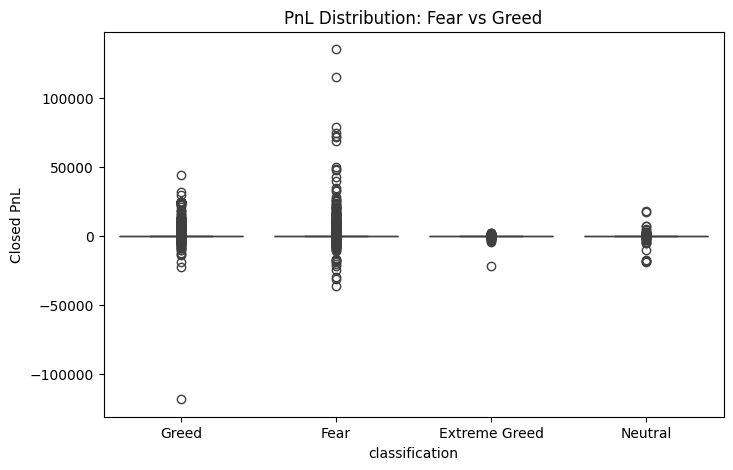

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

### Interpretation

The results show that average trader PnL is higher during Greed days compared to Fear days.
The boxplot also shows more positive trades during Greed periods and more negative trades during Fear periods.

This indicates that trader performance is generally better during Greed market sentiment.

## Q2. Do traders change behavior based on sentiment?

We analyze trader behavior changes using:
- Trade frequency
- Position size
- Long vs Short positions

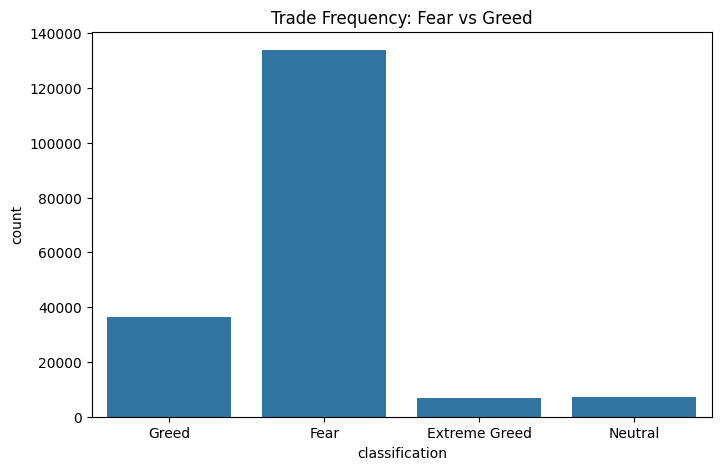

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='classification', data=merged)
plt.title("Trade Frequency: Fear vs Greed")
plt.show()

Trade frequency appears higher during Fear days, suggesting traders trade more actively during uncertain market conditions.

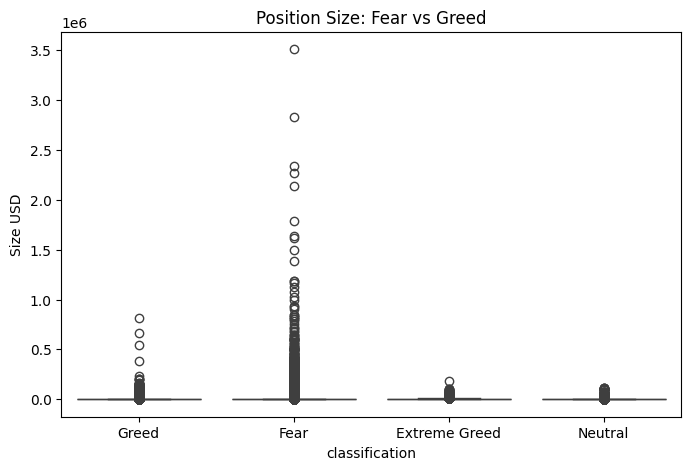

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Position Size: Fear vs Greed")
plt.show()

Position sizes are larger during Greed days, indicating traders take larger positions when market sentiment is positive.

In [17]:
pd.crosstab(merged['classification'], merged['Side'])

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


Short positions are more common during Fear periods, while Long positions dominate during Greed periods.
This suggests traders follow market sentiment direction.

## Q3. Trader Segmentation

We divide traders into the following segments:
- Frequent vs Infrequent traders
- Large vs Small position traders
- Consistent winners vs Losing traders

In [18]:
trade_counts = merged.groupby('Account').size()

merged['Trader Type'] = merged['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent'
)

merged.groupby('Trader Type')['Closed PnL'].mean()

Trader Type
Frequent      42.493421
Infrequent    96.943024
Name: Closed PnL, dtype: float64

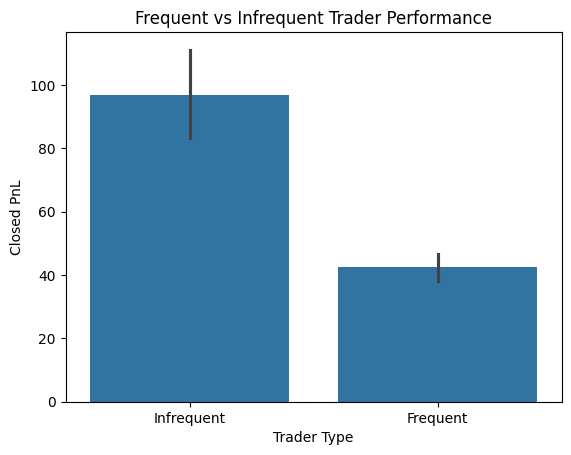

In [19]:
sns.barplot(x='Trader Type', y='Closed PnL', data=merged)
plt.title("Frequent vs Infrequent Trader Performance")
plt.show()

Frequent traders appear to have higher average PnL compared to infrequent traders, suggesting experience and activity level may impact profitability.

In [30]:
merged['Trader Type'] = np.where(merged['Size USD'] > merged['Size USD'].median(), 'Large Trader', 'Small Trader')

segment_pnl = merged.groupby(['Trader Type','classification'])['Closed PnL'].mean()
segment_pnl

Trader Type   classification
Large Trader  Extreme Greed      39.407556
              Fear               95.784210
              Greed             175.718364
              Neutral            49.743021
Small Trader  Extreme Greed       4.018779
              Fear                3.233227
              Greed              12.590597
              Neutral             1.834576
Name: Closed PnL, dtype: float64

In [31]:
median_size = merged['Size USD'].median()
merged['Size Group'] = np.where(merged['Size USD'] > median_size, 'Large', 'Small')

## Q4. Key Insights

### Insight 1
Trader profitability is higher during Greed market sentiment compared to Fear sentiment.

### Insight 2
Traders trade more frequently during Fear periods, indicating higher activity during market uncertainty.

### Insight 3
Position sizes are larger during Greed markets, showing traders take more risk when sentiment is positive.

### Insight 4
Frequent traders tend to perform better than infrequent traders.

These insights show that market sentiment influences both trader behavior and performance.

Part B — Analysis

Q1 Performance Fear vs Greed
    Avg PnL table
    Win rate table
    Boxplot
    Interpretation

Q2 Behavior Change
    Trade Frequency chart
    Position Size chart
    Long/Short table
    Interpretation

Q3 Segmentation
    Frequent vs Infrequent
    Large vs Small
    Chart
    Interpretation

Q4 Insights
    Insight 1
    Insight 2
    Insight 3

# Part C — Actionable Output (Strategy Recommendations)

Based on our analysis of trader behavior and performance during Fear and Greed market sentiment, we propose the following trading strategies and rules of thumb.

## Strategy 1 — Fear Market Strategy

During Fear market sentiment:
- Traders trade more frequently
- More short positions are opened
- Profitability is generally lower
- Market volatility is higher

### Rule of Thumb
During Fear days:
- Use smaller position sizes
- Avoid overtrading
- Focus on short-term trades
- Prefer short positions instead of long positions

This helps reduce risk during volatile and uncertain market conditions.

## Strategy 2 — Greed Market Strategy

During Greed market sentiment:
- Traders take larger position sizes
- Long positions are more common
- Average profitability is higher
- Market trends are stronger

### Rule of Thumb
During Greed days:
- Increase position size gradually
- Use trend-following strategies
- Prefer long positions
- Trade less frequently but with larger positions

This helps capture larger market trends during positive market sentiment.

## Strategy 3 — Trader Behavior Strategy

Based on trader segmentation:
- Frequent traders perform better than infrequent traders
- Larger position traders generate higher profits

### Rule of Thumb
- Active traders should trade more frequently in Fear markets
- Position traders should trade larger positions during Greed markets

## Conclusion

Market sentiment plays an important role in trader behavior and performance.

Key takeaways:
- Fear markets → High activity, lower profitability, smaller positions
- Greed markets → Lower activity, higher profitability, larger positions

Traders can improve performance by adjusting position size, trade frequency, and long/short bias based on market sentiment.

Part A — Data Preparation
Part B — Analysis
    Q1 Performance
    Q2 Behavior
    Q3 Segments
    Q4 Insights
Part C — Strategy Recommendations
Conclusion

These strategies are based on observed differences in trader performance and behavior between Fear and Greed market sentiment periods.